# M0 -- Data Audit

Ayn-VQA (ImageEval 2026, Task 1a, MSA track). This notebook is a runnable
demonstration of the `ayn_vqa` package's M0 milestone: load the JSONL
splits, validate that every referenced image/audio file exists, compute
audio and image statistics, hash images for duplicate detection, and
render a random sample grid -- then generate the full audit report.

No ASR, OCR, or VLM calls happen anywhere in this notebook; that's
deliberately out of scope until M1+ (see
`../../AynVQA-ArabicNLP26/project_analysis_and_plan.md`).

For speed, the exploratory steps below (sections 1-6) run against the
`dev` split only (500 records). Section 7 runs the full production audit
across `train` + `dev` + `devtest` (4,000 records) -- the same command as
`uv run aynvqa-audit` -- and writes the canonical reports to `../reports/`.


In [1]:
import pandas as pd
from IPython.display import Image as IPyImage
from IPython.display import display

from ayn_vqa.audit import audio_stats, hashing, image_stats, run_audit, sampling
from ayn_vqa.config import get_settings
from ayn_vqa.data import loader, schema, validation
from ayn_vqa.logging_utils import setup_logging

setup_logging("INFO")
settings = get_settings()
data_root = settings.resolved_data_root()
print(f"data_root = {data_root}")
print(f"data_root exists = {data_root.exists()}")


data_root = C:\Users\Admin\Documents\AynVQA-ArabicNLP26
data_root exists = True


## 1. Load the dataset

`load_split` parses one `task1a/<split>_<language>.jsonl` file line by
line, validating each row against `Task1aRecord`. It never raises on a
malformed line -- it collects `RecordError`s instead -- because an audit
tool that dies on the first bad row defeats its own purpose.


In [2]:
dev = loader.load_split(data_root, schema.Split.DEV, schema.Language.MSA)
print(f"{len(dev)} records loaded from {dev.jsonl_path.name}")
print(f"{len(dev.errors)} parse errors")
dev.records[0]


500 records loaded from dev_msa.jsonl
0 parse errors


Task1aRecord(id='4a405ef6efd45ecb3c95e0f151ec5c9632a750bdfb2aec7376d23081d10de6a0', image='images/4a405ef6efd45ecb3c95e0f151ec5c9632a750bdfb2aec7376d23081d10de6a0.jpg', audio='audio/msa/4a405ef6efd45ecb3c95e0f151ec5c9632a750bdfb2aec7376d23081d10de6a0.wav', label=0, country='Algeria', category='Objects, Materials & Clothing', subcategory='Everyday Objects')

## 2. Validate media paths

For every record, `validate_split_media` checks both the `image` and
`audio` file it points to and reports whether each one actually exists on
disk -- the single check this whole milestone exists to run.


In [3]:
dev_checks = validation.validate_split_media(dev, data_root)
missing = validation.missing_media(dev_checks)
print(f"{len(dev_checks)} media files checked, {len(missing)} missing")
missing[:5]


1000 media files checked, 0 missing


[]

## 3. Audio statistics

`probe_audio` reads only the WAV header via `soundfile` (libsndfile) --
not the full sample buffer -- so this is fast even across thousands of
files.


In [4]:
dev_audio_stats = [audio_stats.probe_audio(r.id, r.audio_path(data_root)) for r in dev.records]
audio_df = pd.DataFrame([vars(s) for s in dev_audio_stats])
print(f"unreadable: {audio_df['error'].notna().sum()}")
audio_df[["duration_sec", "sample_rate", "channels"]].describe()


unreadable: 0


,duration_sec,sample_rate,channels
count,500.000000,500.0,500.0
mean,17.819042,24000.0,1.0
std,3.384937,0.0,0.0
min,10.152958,24000.0,1.0
25%,15.545125,24000.0,1.0
50%,17.476292,24000.0,1.0
75%,19.852292,24000.0,1.0
max,29.972292,24000.0,1.0


In [5]:
ax = audio_df["duration_sec"].dropna().plot(
    kind="hist", bins=30, title="dev/msa audio duration (s)"
)
ax.set_xlabel("duration (s)")


Text(0.5, 0, 'duration (s)')

## 4. Image statistics

`probe_image` uses Pillow's lazy header read for width/height/format/mode,
and explicitly surfaces animated GIFs (`is_animated`, `n_frames`) since a
naive "just open it as a static image" approach would silently take only
the first frame with no signal that anything was lost.


In [6]:
dev_image_stats = [image_stats.probe_image(r.id, r.image_path(data_root)) for r in dev.records]
image_df = pd.DataFrame([vars(s) for s in dev_image_stats])
print(f"unreadable: {image_df['error'].notna().sum()}")
print(image_df["format"].value_counts(dropna=False))
image_df[["width", "height"]].describe()


unreadable: 0
format
JPEG    478
PNG      22
Name: count, dtype: int64


,width,height
count,500.000000,500.000000
mean,1233.778000,994.504000
std,260.085397,228.798968
min,150.000000,100.000000
25%,1080.000000,810.000000
50%,1280.000000,957.000000
75%,1300.000000,1080.000000
max,2049.000000,1743.000000


In [7]:
ax = image_df.plot.scatter(x="width", y="height", s=8, alpha=0.4, title="dev/msa image resolution")


## 5. Random sample visualization

Train/dev rows are sorted alphabetically by country in the source JSONL,
so `sample_records` always draws with `random.Random(seed)` -- never a
slice -- to avoid silently sampling one country.


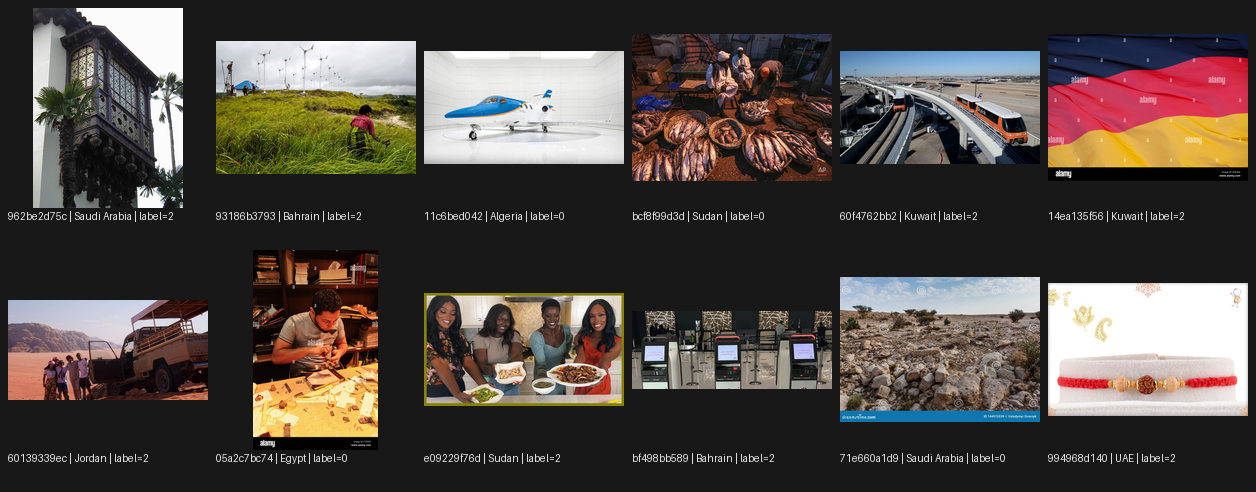

In [8]:
sampled = sampling.sample_records(dev.records, n=12, seed=settings.random_seed)
figures_dir = settings.resolved_reports_dir() / "m0_data_audit" / "figures"
out_path = figures_dir / "notebook_sample_grid.png"
grid_path = sampling.render_sample_grid(sampled, data_root, out_path)
display(IPyImage(filename=str(grid_path)))


## 6. Duplicate image detection

Two independent checks: SHA-256 over the raw bytes (byte-identical files
reused under two ids) and a perceptual difference-hash, dHash (the same
picture re-encoded or resized under two ids -- something byte hashing
cannot catch). See `ayn_vqa/audit/hashing.py` for why plain O(n^2) is the
right call at this dataset's size.


In [9]:
sha_by_id, phash_by_id = run_audit._hash_images(dev.records, data_root)
exact_groups = hashing.group_exact_duplicates(sha_by_id)
near_pairs = hashing.find_near_duplicates(phash_by_id, max_distance=settings.near_dup_max_distance)
print(f"exact-duplicate groups in dev/msa: {len(exact_groups)}")
print(f"near-duplicate pairs in dev/msa: {len(near_pairs)}")
near_pairs[:5]


exact-duplicate groups in dev/msa: 0
near-duplicate pairs in dev/msa: 0


[]

## 7. Full audit report

Runs the complete M0 pipeline across `train` + `dev` + `devtest` (4,000
records) -- identical to `uv run aynvqa-audit` -- and writes
`file_manifest.csv`, `duplicate_images.csv`, `audit_summary.json`,
`audit_report.md`, and the figures under `../reports/m0_data_audit/`.


In [10]:
report_paths = run_audit.run_audit(
    data_root=data_root,
    output_dir=settings.resolved_reports_dir() / "m0_data_audit",
    language=schema.Language.MSA,
    splits=(schema.Split.TRAIN, schema.Split.DEV, schema.Split.DEVTEST),
    sample_n=settings.sample_grid_n,
    near_dup_max_distance=settings.near_dup_max_distance,
    seed=settings.random_seed,
)
report_paths


[20:12:23] INFO     Loading train/msa ...

           INFO     train/msa: 3000 records loaded, 0 parse errors

[20:12:24] INFO     Loading dev/msa ...

           INFO     dev/msa: 500 records loaded, 0 parse errors

           INFO     Loading devtest/msa ...

...

[20:12:53] ERROR    Failed to hash image for record                                                                
                    f2b1cfbeac305700ff2799c9ad19731549caaf18a5a7dac749cd9ae726cfe861                               
                    (C:\Users\Admin\Documents\AynVQA-ArabicNLP26\images\f2b1cfbeac305700ff2799c9ad19731549caaf18a5a
                    7dac749cd9ae726cfe861.gif)                                                                     
                    ╭───────────────────────────── Traceback (most recent call last) ─────────────────────────────╮
                    │ C:\Users\Admin\Documents\ayn-vqa-msa\src\ayn_vqa\audit\run_audit.py:76 in _hash_images      │
                    │                                                                                             │
                    │    73 │   │   │   continue  # already reported as missing by validate_split_media           │
                    │    74 │   │   try:                                                                          │
                    │    75 │   │   │   sha_by_id[record.id] = sha256_file(path)                                  │
                    │ ❱  76 │   │   │   phash_by_id[record.id] = dhash(path)                                      │
                    │    77 │   │   except Exception:                                                             │
                    │    78 │   │   │   logger.exception("Failed to hash image for record %s (%s)", record.id, pa │
                    │    79 │   return sha_by_id, phash_by_id                                                     │
                    │                                                                                             │
                    │ C:\Users\Admin\Documents\ayn-vqa-msa\src\ayn_vqa\audit\hashing.py:50 in dhash               │
                    │                                                                                             │
                    │    47 │   -- exactly the transformations that would defeat a byte-exact hash on a           │
                    │    48 │   re-saved duplicate -- while needing only Pillow, no extra dependency.             │
                    │    49 │   """                                                                               │
                    │ ❱  50 │   with Image.open(path) as img:                                                     │
                    │    51 │   │   # (hash_size + 1) columns so every one of the `hash_size` columns             │
                    │    52 │   │   # has a right-hand neighbor to compare against.                               │
                    │    53 │   │   small = img.convert("L").resize((hash_size + 1, hash_size),                   │
                    │       Image.Resampling.LANCZOS)                                                             │
                    │                                                                                             │
                    │ C:\Users\Admin\Documents\ayn-vqa-msa\.venv\Lib\site-packages\PIL\Image.py:3715 in open      │
                    │                                                                                             │
                    │   3712 │   for message in warning_messages:                                                 │
                    │   3713 │   │   warnings.warn(message)                                                       │
                    │   3714 │   msg = "cannot identify image file %r" % (filename if filename else fp)           │
                    │ ❱ 3715 │   raise UnidentifiedImageError(msg)                                                │
                    │   3716                                                                                      │
                    │   3717                                                                                      │
                    │   3718 #                          

[20:12:59] INFO     Duplicate scan: 0 exact-duplicate groups, 3 near-duplicate pairs

           INFO     Rendering random sample grid (n=24, seed=42) ...

           INFO     Wrote audit reports to C:\Users\Admin\Documents\ayn-vqa-msa\reports\m0_data_audit

ReportPaths(manifest_csv=WindowsPath('C:/Users/Admin/Documents/ayn-vqa-msa/reports/m0_data_audit/file_manifest.csv'), duplicates_csv=WindowsPath('C:/Users/Admin/Documents/ayn-vqa-msa/reports/m0_data_audit/duplicate_images.csv'), summary_json=WindowsPath('C:/Users/Admin/Documents/ayn-vqa-msa/reports/m0_data_audit/audit_summary.json'), report_md=WindowsPath('C:/Users/Admin/Documents/ayn-vqa-msa/reports/m0_data_audit/audit_report.md'), figures=[WindowsPath('C:/Users/Admin/Documents/ayn-vqa-msa/reports/m0_data_audit/figures/audio_duration_hist.png'), WindowsPath('C:/Users/Admin/Documents/ayn-vqa-msa/reports/m0_data_audit/figures/image_resolution_scatter.png'), WindowsPath('C:/Users/Admin/Documents/ayn-vqa-msa/reports/m0_data_audit/figures/image_format_counts.png'), WindowsPath('C:/Users/Admin/Documents/ayn-vqa-msa/reports/m0_data_audit/figures/country_counts.png')], sample_grid=WindowsPath('C:/Users/Admin/Documents/ayn-vqa-msa/reports/m0_data_audit/figures/sample_grid.png'))

In [11]:
print((report_paths.report_md).read_text(encoding="utf-8"))


# M0 Data Audit Report

Total records audited: **4000**

## Records per split/language
| split   | language   |   n_records |
|:--------|:-----------|------------:|
| dev     | msa        |         500 |
| devtest | msa        |         500 |
| train   | msa        |        3000 |

## Media integrity
- Missing images: **0**
- Missing audio: **0**
- Present-but-unreadable images: **3**
- Present-but-unreadable audio: **0**

### JSONL parse errors by split
- `train_msa`: 0
- `dev_msa`: 0
- `devtest_msa`: 0

## Image statistics
- Formats: `{'JPEG': 3816, 'PNG': 181, 'nan': 3}`
- Animated GIFs: 0

![Image resolution scatter](figures/image_resolution_scatter.png)

![Image format counts](figures/image_format_counts.png)

## Audio statistics
- Sample rates: `{'24000': 4000}`
- Channels: `{'1': 4000}`
- Duration (s): mean=17.86, median=17.48, min=8.30, max=33.93

![Audio duration histogram](figures/audio_duration_hist.png)

## Label / country / category distribution
- Labels: `{'2': 1196, '1':

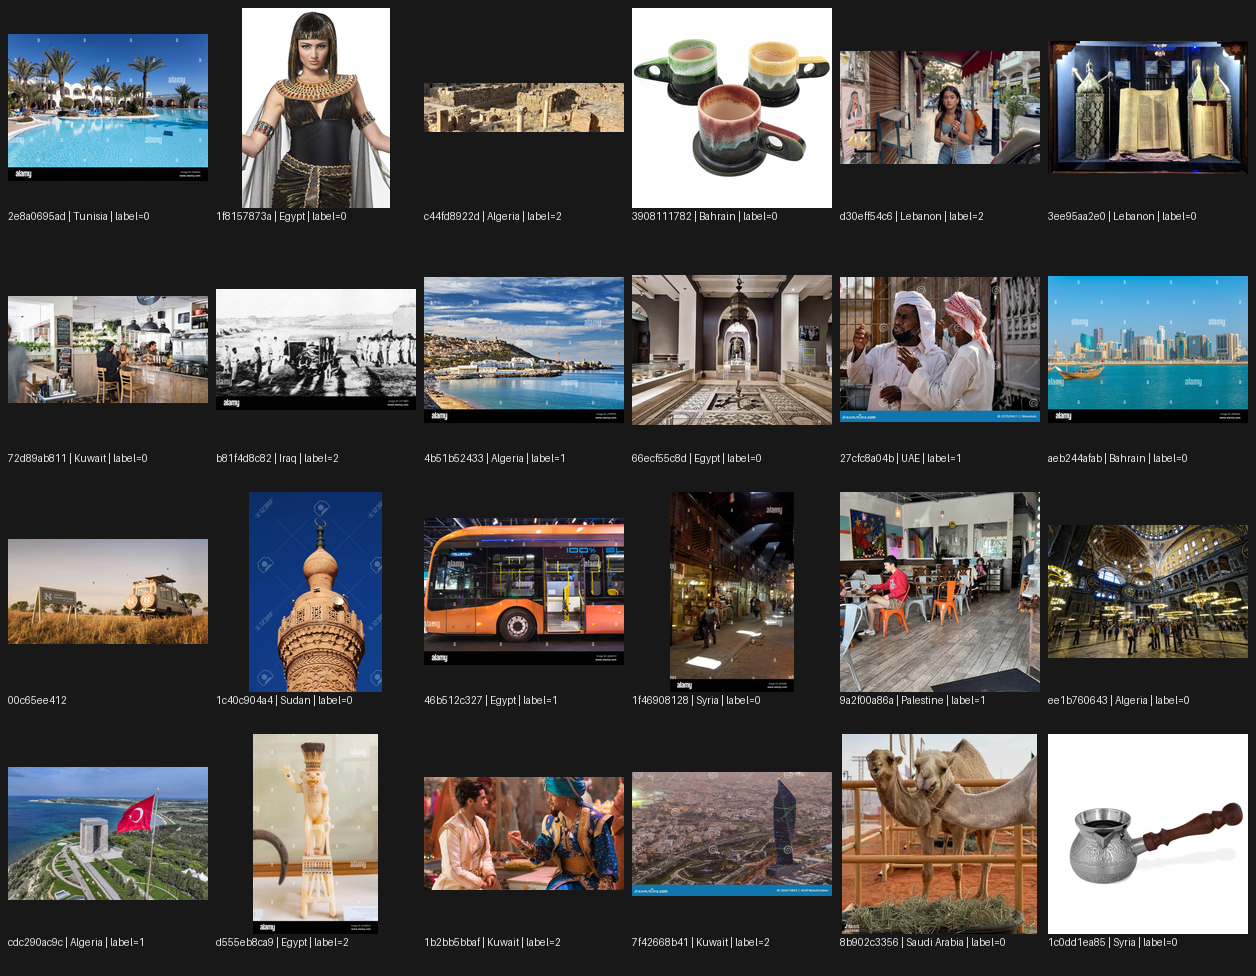

In [12]:
display(IPyImage(filename=str(report_paths.sample_grid)))


## 8. Key findings from this run

- **4,000 MSA-track records** (3,000 train / 500 dev / 500 devtest); every
  `image`/`audio` path referenced in the JSONL resolves to a file on disk
  (0 missing).
- **3 images are present but undecodable.** All three are the "GIF"
  entries the project's data-analysis notes had flagged; inspecting the
  raw bytes shows they are un-smudged **Git LFS pointer stubs** (134-byte
  text files, not real image data) -- `git lfs pull` on the dataset clone
  should be re-run to materialize them. This is exactly the class of
  silent failure this milestone exists to catch before any ASR/VLM call
  ever touches these three ids.
- **Audio is uniformly 24 kHz mono**, duration 8.3-33.9s (mean 17.9s,
  median 17.5s) -- this had only been guessed at before M0.
- **0 exact-duplicate images, 3 near-duplicate pairs** (perceptual hash,
  Hamming distance <= 4) -- a real, previously-unverified risk from the
  project's leakage checklist, now measured.
- **Country balance holds under combined train+dev**, with one exception:
  Iraq sits at ~166 records vs. ~196-197 for every other of the 18
  countries -- worth remembering as a diagnostics caveat, not a bug.

Next: **M1 -- repo skeleton + trivial baselines** (see the roadmap in
`project_analysis_and_plan.md`). Nothing here should change before then;
M0's job was strictly to characterize the data, not to act on it.
